# Customer Churn Prediction
**Dataset:** Telco Customer Churn (Kaggle)

---

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
import joblib

print('Libraries loaded')

Libraries loaded


## 1. Load & inspect data

In [18]:
df = pd.read_csv('../data/churn.csv')
print(f'Shape: {df.shape}')
print(f'\nColumn types:\n{df.dtypes}')
print(f'\nMissing values:\n{df.isnull().sum()}')
df.head()

Shape: (7043, 21)

Column types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract          

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Fix data issues

In [19]:
# TotalCharges is stored as string — real data quality issue!
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'Rows with NaN TotalCharges: {df["TotalCharges"].isnull().sum()}')
df.dropna(inplace=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(f'\nChurn distribution:\n{df["Churn"].value_counts()}')
print(f'Churn rate: {df["Churn"].mean():.1%}')

Rows with NaN TotalCharges: 11

Churn distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64
Churn rate: 26.6%


## 3. Exploratory data analysis

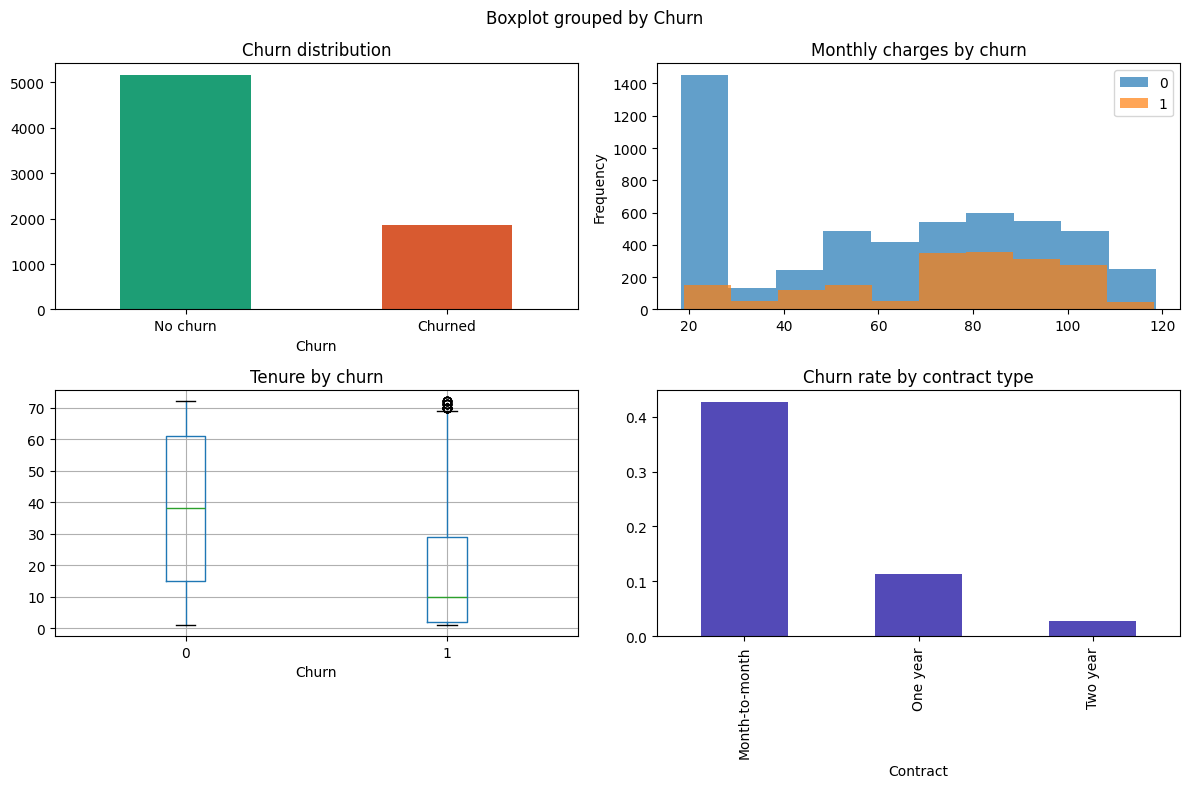

Key finding: Month-to-month contracts have highest churn rate


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Churn rate
df['Churn'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#1D9E75','#D85A30'])
axes[0,0].set_title('Churn distribution')
axes[0,0].set_xticklabels(['No churn','Churned'], rotation=0)

# Monthly charges by churn
df.groupby('Churn')['MonthlyCharges'].plot(kind='hist', ax=axes[0,1], alpha=0.7, legend=True)
axes[0,1].set_title('Monthly charges by churn')

# Tenure by churn
df.boxplot(column='tenure', by='Churn', ax=axes[1,0])
axes[1,0].set_title('Tenure by churn')

# Contract type churn rate
df.groupby('Contract')['Churn'].mean().plot(kind='bar', ax=axes[1,1], color='#534AB7')
axes[1,1].set_title('Churn rate by contract type')

plt.tight_layout()
plt.savefig('eda_charts.png', dpi=100, bbox_inches='tight')
plt.show()
print('Key finding: Month-to-month contracts have highest churn rate')

## 4. Train the model

In [21]:
# Encode categorical columns
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'customerID']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

X = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {len(X_train)}, Test size: {len(X_test)}')
print(f'Churn rate in test set: {y_test.mean():.1%}')

Train size: 5625, Test size: 1407
Churn rate in test set: 26.6%


In [22]:
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print('=== MODEL RESULTS (put these in your CV!) ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred):.2%}')
print(f'F1 Score:  {f1_score(y_test, y_pred):.2%}')
print(f'AUC-ROC:   {roc_auc_score(y_test, y_prob):.2%}')
print(f'\nClassification report:')
print(classification_report(y_test, y_pred, target_names=['No churn','Churned']))

=== MODEL RESULTS (put these in your CV!) ===
Accuracy:  78.11%
F1 Score:  53.61%
AUC-ROC:   81.29%

Classification report:
              precision    recall  f1-score   support

    No churn       0.82      0.89      0.86      1033
     Churned       0.61      0.48      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407



## 5. Feature importance

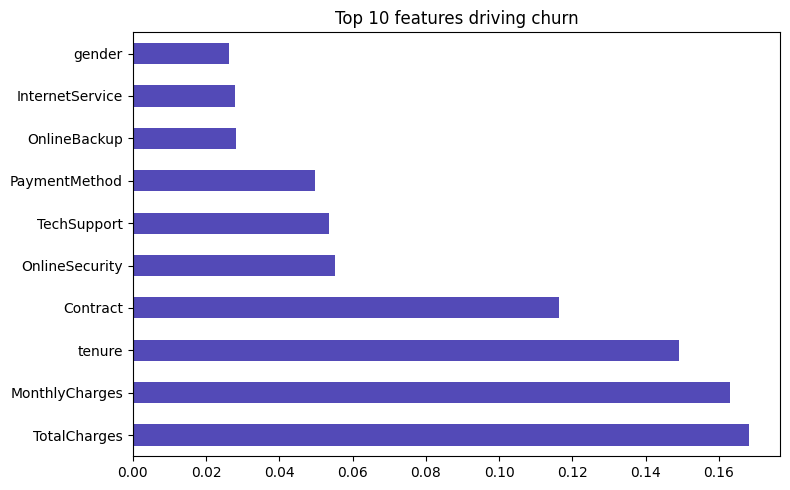

These are the features that matter most for churn prediction


In [23]:
importances = pd.Series(model.feature_importances_, index=X.columns)
top10 = importances.nlargest(10)

top10.plot(kind='barh', color='#534AB7', figsize=(8, 5))
plt.title('Top 10 features driving churn')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100)
plt.show()
print('These are the features that matter most for churn prediction')

## 6. Save the model

In [24]:
joblib.dump(model, '../model/churn_model.pkl')
print('Model saved to model/churn_model.pkl')
print('Now run: uvicorn main:app --reload')

Model saved to model/churn_model.pkl
Now run: uvicorn main:app --reload
